In [57]:
# Week 7 Initial Start on project

import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt

# Load data
inspection = pd.read_csv('/Users/kamilalim/Desktop/Wellesley/Semester_8/DS 340H/Week5/Boston_inspection.csv')

/var/folders/6_/l68l87gx1dlg999n_t092b7w0000gn/T/ipykernel_12651/3583679842.py:9: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  inspection = pd.read_csv('/Users/kamilalim/Desktop/Wellesley/Semester_8/DS 340H/Week5/Boston_inspection.csv')


In [58]:
# Explore data

print("Shape is: " + str(inspection.shape))
print("Columns are: " + str(inspection.columns))
print(inspection.info())

Shape is: (871066, 26)
Columns are: Index(['businessname', 'dbaname', 'legalowner', 'namelast', 'namefirst',
       'licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',
       'descript', 'result', 'resultdttm', 'violation', 'viol_level',
       'violdesc', 'violdttm', 'viol_status', 'status_date', 'comments',
       'address', 'city', 'state', 'zip', 'property_id', 'location'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871066 entries, 0 to 871065
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   businessname  871066 non-null  object 
 1   dbaname       8294 non-null    object 
 2   legalowner    567638 non-null  object 
 3   namelast      871066 non-null  object 
 4   namefirst     500708 non-null  object 
 5   licenseno     871066 non-null  int64  
 6   issdttm       870217 non-null  object 
 7   expdttm       870433 non-null  object 
 8   licstatus     871066 non-null  

In [59]:
# Define standardization functions: Business name, address, category of business

# Standardize the name of all businesses to be: lowercase, take out suffixes and punction, and remove trailing digits
def standardize_name(name):
    if pd.isna(name): return "unknown"
    name = str(name).lower()
    name = re.sub(r'\bno\b', '', name)
    name = re.sub(r'\b(llc|inc|corp|corporation|ltd|group|co|company)\b', '', name)
    name = re.sub(r'[^\w\s]', '', name)
    name = re.sub(r'\b(\w)\s+(\w)\b', r'\1\2', name)
    return " ".join(name.split())

def standardize_address(addr):
    if pd.isna(addr): return "unknown"
    addr = str(addr).lower()
    # Remove floor/unit/suite info
    addr = re.sub(r'\b(fl|floor|unit|ste|suite|level|rm|room|#)\b.*$', '', addr)
    # Standardize street suffixes
    addr = re.sub(r'\bst\b|\bstreet\b', 'st', addr)
    addr = re.sub(r'\bave\b|\bavenue\b', 'ave', addr)
    addr = re.sub(r'\brd\b|\broad\b', 'rd', addr)
    # Remove punctuation
    addr = re.sub(r'[^\w\s]', '', addr)
    # FINAL SAFETY: Take only the first 3 components (e.g., "100" "main" "st")
    # This ignores trailing ZIP codes or extra descriptors
    return " ".join(addr.split()[:3])

def categorize_business(row):
    if row['name_loc_count'] >= 2:
        return 'Brand Chain'
    elif row['owner_loc_count'] >= 2:
        return 'Institutional/Owner Chain'
    return 'Independent'

In [60]:
# Clean the data: Add each of these defined functions to the dataset

# Only keep businesses that are currently in business
inspection = inspection[inspection['licstatus'] == 'Active'].copy()

inspection['businessname_clean'] = inspection['businessname'].apply(standardize_name)
inspection['legalowner_clean'] = inspection['legalowner'].apply(standardize_name)
inspection['address_clean'] = inspection['address'].apply(standardize_address)

# Check to see what most common business names are
print(inspection['businessname_clean'].value_counts().head(10))

dunkin donuts         4526
subway                1893
caffe nero            1834
the real deal         1805
mcdonalds             1754
burger king           1551
flames restaurant     1298
whole foods market    1086
chilacates            1085
yelys coffee shop     1065
Name: businessname_clean, dtype: int64


In [61]:
# Count the counts for each business

######## Find unique businesses and then group them by name and owner (separately)

# Each business may have multiple rows for each violation
# Create a new column (name_loc_count) that gives the number of businesses with the same name, accounting for the 
    # fact that one location may have multiple rows in the dataset
# THen do same for owners
name_counts = inspection.groupby('businessname_clean')['address_clean'].nunique().rename('name_loc_count')
    # Group businesses only when they have a unique address with .grouby and 'address'.nunique()
    # Ex. Dunkin at 100 main st inspected 100 times is counted as 1 location
owner_counts = inspection.groupby('legalowner_clean')['address_clean'].nunique().rename('owner_loc_count')

inspection = inspection.merge(name_counts, on='businessname_clean', how='left')
inspection = inspection.merge(owner_counts, on='legalowner_clean', how='left')

In [62]:
# Categorize businesses into brand chain, owner chain, independent

# Create a new column variable for whether the business is a brand chain, independent, or institutional chain
inspection['analysis_group'] = inspection.apply(categorize_business, axis=1)
# Create new column for whether is a general chain
inspection['is_chain'] = inspection['analysis_group'] != 'Independent'

print("--- Breakdown by Analysis Group ---")
print(inspection['analysis_group'].value_counts())

print("\n--- Unique Business Names identified as Chains ---")
chain_names_count = inspection[inspection['is_chain'] == True]['businessname_clean'].nunique()
print(f"Total: {chain_names_count}")

--- Breakdown by Analysis Group ---
Independent                  196172
Institutional/Owner Chain    184027
Brand Chain                   53695
Name: analysis_group, dtype: int64

--- Unique Business Names identified as Chains ---
Total: 2210


In [63]:
# Clean up code from here down. Move comments up. Move print statements up

In [64]:
# Create a list of 20 random chains to see the variety and verify
sample_chains = inspection[inspection['is_chain'] == True]['businessname_clean'].unique()
print(sample_chains[:20])

['110 grill' '129 lake street cafe' '149 eat street'
 '163 vietnamese sandwich' '1st floor cafe tufts medical center'
 '211 better bagels' '21 st amendment' '320 cafe'
 '3rd floor tufts medical center' '410 north end butcher' '417sals pizza'
 '5050 lounge' '521 function kitchen' '5w bar' '6oi kitchen'
 '728 causeway cones' '75 on liberty wharf' '89 charles'
 '99 restaurant and pub' '9 thai express']


In [65]:
# Print out a few of each category of business to verify
for group in ['Brand Chain', 'Institutional/Owner Chain', 'Independent']:
    print(f"\n--- SAMPLE OF: {group} ---")
    
    # Get unique business names for this group
    unique_names = inspection[inspection['analysis_group'] == group]['businessname_clean'].unique()
    
    # Print the first 15 (or fewer if the list is short)
    print(unique_names[:15])


--- SAMPLE OF: Brand Chain ---
['ab burgers' 'amelias taqueria' 'americas food basket' 'annas taqueria'
 'anoush ella' 'bailey and sage' 'barrys bootcamp' 'bartaco' 'bbq chicken'
 'bean leaf cafe' 'beantown pastrami' 'ben jerrys'
 'bennetts sandwich shop' 'blanchards' 'blank street coffee']

--- SAMPLE OF: Institutional/Owner Chain ---
['110 grill' '129 lake street cafe' '149 eat street'
 '163 vietnamese sandwich' '1st floor cafe tufts medical center'
 '211 better bagels' '21 st amendment' '320 cafe'
 '3rd floor tufts medical center' '410 north end butcher' '417sals pizza'
 '5050 lounge' '521 function kitchen' '5w bar' '6oi kitchen']

--- SAMPLE OF: Independent ---
['100 federal market barista 10th floor'
 '100 federal market barista 11th floor'
 '100 federal smoothie bar 11th floor' '10eleven food shop'
 '1928 beacon hill' '1928 rowes wharf' '200 club 3rd fl'
 '20th centry bowling lanes' '224 boston' '311' '753 south' '75 chestnut'
 '7 to 11 convenience' '89 broad streetfin point' 'a

In [66]:
# See exactly which addresses are triggering the 'Chain' status for a business
print(inspection[inspection['businessname_clean'] == '2twenty2']['address_clean'].unique())

##### 2twenty2 has 2 locations. Both of them closed. 

[]


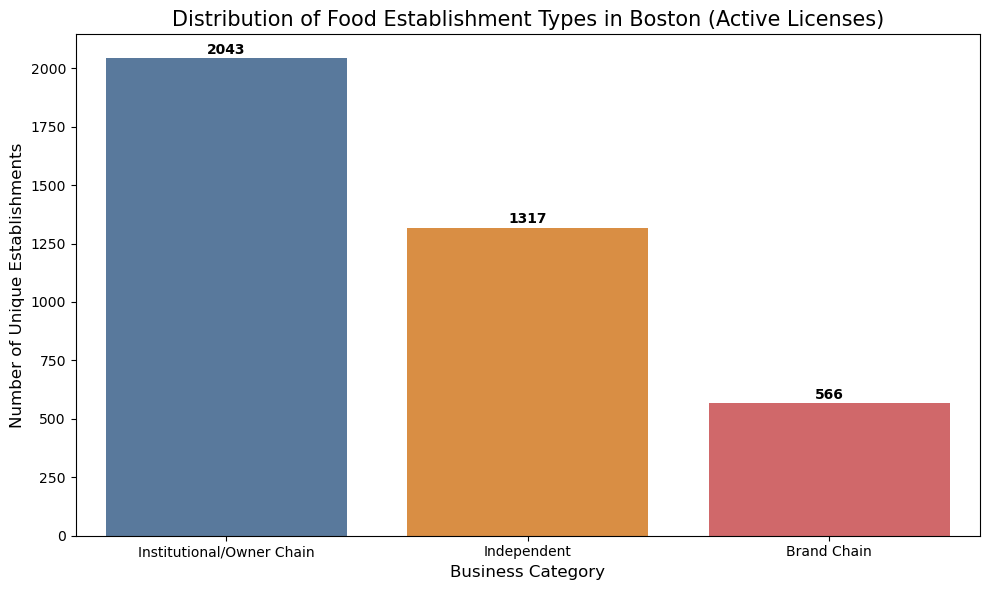

In [67]:
# Graphic creation to show the difference in chains vs independents

group_counts = inspection.drop_duplicates(subset=['businessname_clean', 'address_clean'])['analysis_group'].value_counts()

# 2. Create the Plot
plt.figure(figsize=(10, 6))
colors = ['#4e79a7', '#f28e2b', '#e15759'] # Professional blue, orange, red palette

sns.barplot(x=group_counts.index, y=group_counts.values, palette=colors)

# 3. Add Labels and Title
plt.title('Distribution of Food Establishment Types in Boston (Active Licenses)', fontsize=15)
plt.ylabel('Number of Unique Establishments', fontsize=12)
plt.xlabel('Business Category', fontsize=12)

# 4. Add data labels on top of bars
for i, v in enumerate(group_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [68]:
# Check how Starbucks is being categorized
starbucks_check = inspection[inspection['businessname_clean'].str.contains('starbucks')].iloc[0]

print(f"Name: {starbucks_check['businessname_clean']}")
print(f"Name Count: {starbucks_check['name_loc_count']}")
print(f"Owner Count: {starbucks_check['owner_loc_count']}")
print(f"Final Category: {starbucks_check['analysis_group']}")

Name: breadwinnersstarbucks
Name Count: 1
Owner Count: 1162
Final Category: Institutional/Owner Chain
